In [1]:
!pip install numpy pandas matplotlib scikit-learn statsmodels xgboost torch joblib

In [2]:
import os
import zipfile
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [4]:
PROJECT_DIR = r"E:\MY projects\Flash Flood Prediction Project"

DATA_ZIP = os.path.join(
    PROJECT_DIR,
    "data",
    "DEM_monthly.zip"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "DEM"
)

os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset:", DATA_ZIP)
print("Model directory:", MODEL_DIR)

Dataset: E:\MY projects\Flash Flood Prediction Project\data\DEM_monthly.zip
Model directory: E:\MY projects\Flash Flood Prediction Project\models\DEM


In [5]:
data_list = []
empty_files = []

with zipfile.ZipFile(DATA_ZIP, "r") as z:

    csv_files = [
        name for name in z.namelist()
        if name.lower().endswith(".csv")
    ]

    print("CSV files found:", len(csv_files))

    for file in csv_files:

        try:
            with z.open(file) as f:
                temp = pd.read_csv(f)

            if temp.empty:
                empty_files.append(file)
                continue

            data_list.append(temp)

        except Exception as e:
            print("Error reading:", file)
            print(e)

print("Valid files:", len(data_list))
print("Empty files:", len(empty_files))

CSV files found: 80
Valid files: 80
Empty files: 0


In [6]:
df = pd.concat(
    data_list,
    ignore_index=True
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (80, 5)


,year,month,elevation_mean_m,elevation_min_m,elevation_max_m
0,2020,1,2721.837517,1186,4751
1,2020,2,2721.837517,1186,4751
2,2020,3,2721.837517,1186,4751
3,2020,4,2721.837517,1186,4751
4,2020,5,2721.837517,1186,4751


In [7]:
df["year"] = pd.to_numeric(
    df["year"],
    errors="coerce"
)

df["month"] = pd.to_numeric(
    df["month"],
    errors="coerce"
)

df["elevation_mean_m"] = pd.to_numeric(
    df["elevation_mean_m"],
    errors="coerce"
)

df["elevation_min_m"] = pd.to_numeric(
    df["elevation_min_m"],
    errors="coerce"
)

df["elevation_max_m"] = pd.to_numeric(
    df["elevation_max_m"],
    errors="coerce"
)

df = df.dropna()

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna()

df = df.sort_values(
    ["year", "month"]
).reset_index(drop=True)

print(df.shape)
display(df.head())

(80, 5)


,year,month,elevation_mean_m,elevation_min_m,elevation_max_m
0,2020,1,2721.837517,1186,4751
1,2020,2,2721.837517,1186,4751
2,2020,3,2721.837517,1186,4751
3,2020,4,2721.837517,1186,4751
4,2020,5,2721.837517,1186,4751


In [8]:
df["datetime"] = pd.to_datetime(
    df["year"].astype(int).astype(str)
    + "-"
    + df["month"].astype(int).astype(str)
    + "-01"
)

df = df.sort_values("datetime").reset_index(drop=True)

display(df.head())
display(df.tail())

,year,month,elevation_mean_m,elevation_min_m,elevation_max_m,datetime
0,2020,1,2721.837517,1186,4751,2020-01-01
1,2020,2,2721.837517,1186,4751,2020-02-01
2,2020,3,2721.837517,1186,4751,2020-03-01
3,2020,4,2721.837517,1186,4751,2020-04-01
4,2020,5,2721.837517,1186,4751,2020-05-01


,year,month,elevation_mean_m,elevation_min_m,elevation_max_m,datetime
75,2026,4,2721.837517,1186,4751,2026-04-01
76,2026,5,2721.837517,1186,4751,2026-05-01
77,2026,6,2721.837517,1186,4751,2026-06-01
78,2026,7,2721.837517,1186,4751,2026-07-01
79,2026,8,2721.837517,1186,4751,2026-08-01


In [9]:
print(df["elevation_mean_m"].describe())

count    8.000000e+01
mean     2.721838e+03
std      4.576164e-13
min      2.721838e+03
25%      2.721838e+03
50%      2.721838e+03
75%      2.721838e+03
max      2.721838e+03
Name: elevation_mean_m, dtype: float64


In [10]:
print(
    "Unique mean elevation values:",
    df["elevation_mean_m"].nunique()
)

Unique mean elevation values: 1


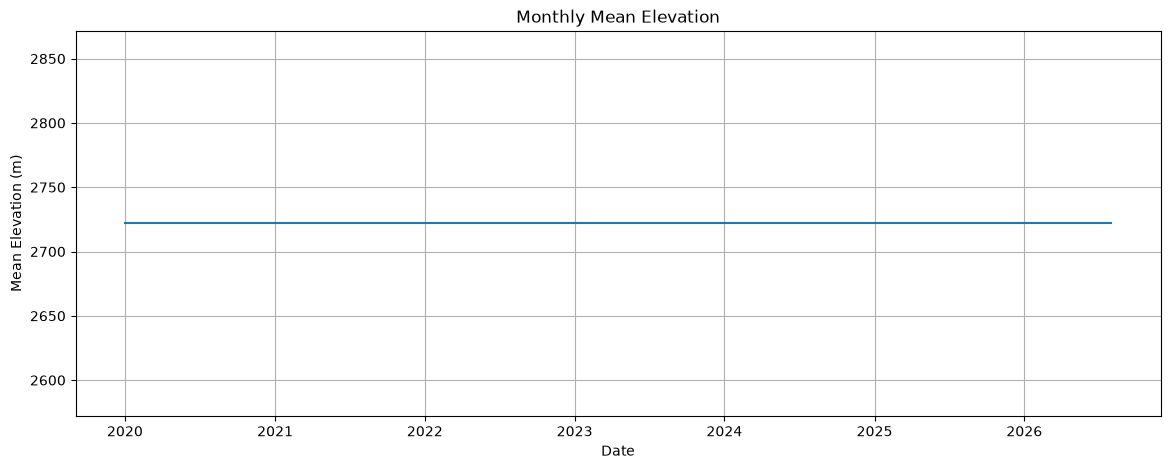

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["datetime"],
    df["elevation_mean_m"]
)

plt.xlabel("Date")
plt.ylabel("Mean Elevation (m)")
plt.title("Monthly Mean Elevation")

plt.grid(True)
plt.show()

In [12]:
series = df[
    ["datetime", "elevation_mean_m"]
].copy()

series = series.set_index("datetime")

y = series["elevation_mean_m"].astype(float)

print(y.shape)
print(y.head())

(80,)
datetime
2020-01-01    2721.837517
2020-02-01    2721.837517
2020-03-01    2721.837517
2020-04-01    2721.837517
2020-05-01    2721.837517
Name: elevation_mean_m, dtype: float64


In [13]:
print("NaN:", y.isna().sum())
print("Inf:", np.isinf(y).sum())
print("Min:", y.min())
print("Max:", y.max())

NaN: 0
Inf: 0
Min: 2721.837517392416
Max: 2721.837517392416


In [14]:
assert np.isfinite(y.values).all(), "Dataset contains NaN or Inf!"

In [15]:
split_index = int(len(y) * 0.8)

train = y.iloc[:split_index]
test = y.iloc[split_index:]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 64
Testing samples: 16


In [16]:
print("Training ARIMA...")

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(test)
)

arima_pred = np.asarray(arima_pred)

arima_pred = np.nan_to_num(
    arima_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print("ARIMA completed!")

Training ARIMA...
ARIMA completed!


In [17]:
print("Training SARIMAX...")

sarimax_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(
    disp=False
)

sarimax_pred = sarimax_fit.forecast(
    steps=len(test)
)

sarimax_pred = np.asarray(sarimax_pred)

sarimax_pred = np.nan_to_num(
    sarimax_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print("SARIMAX completed!")

Training SARIMAX...
SARIMAX completed!


In [18]:
xgb_df = pd.DataFrame({
    "value": y
})

for lag in [1, 2, 3, 6, 12]:

    xgb_df[f"lag_{lag}"] = (
        xgb_df["value"].shift(lag)
    )

xgb_df["month"] = xgb_df.index.month
xgb_df["year"] = xgb_df.index.year

xgb_df = xgb_df.dropna()

display(xgb_df.head())

,value,lag_1,lag_2,lag_3,lag_6,lag_12,month,year
datetime,,,,,,,,
2021-01-01,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,1,2021
2021-02-01,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,2,2021
2021-03-01,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,3,2021
2021-04-01,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,4,2021
2021-05-01,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,2721.837517,5,2021


In [19]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "month",
    "year"
]

X = xgb_df[features]
Y = xgb_df["value"]

In [20]:
xgb_split = int(len(X) * 0.8)

X_train = X.iloc[:xgb_split]
X_test = X.iloc[xgb_split:]

Y_train = Y.iloc[:xgb_split]
Y_test = Y.iloc[xgb_split:]

print(X_train.shape)
print(X_test.shape)

(54, 7)
(14, 7)


In [21]:
print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cuda" if torch.cuda.is_available() else "cpu",
    random_state=42
)

xgb_model.fit(
    X_train,
    Y_train
)

xgb_pred = xgb_model.predict(X_test)

xgb_pred = np.nan_to_num(
    xgb_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print("XGBoost completed!")

Training XGBoost...
XGBoost completed!


In [22]:
values = y.values.reshape(-1, 1)

scaler = StandardScaler()

scaled_values = scaler.fit_transform(values)

print("Scaled min:", scaled_values.min())
print("Scaled max:", scaled_values.max())

Scaled min: 4.547473508864641e-13
Scaled max: 4.547473508864641e-13


In [23]:
SEQUENCE_LENGTH = 12

def create_sequences(data, seq_length):

    X = []
    Y = []

    for i in range(len(data) - seq_length):

        X.append(
            data[i:i + seq_length]
        )

        Y.append(
            data[i + seq_length]
        )

    return (
        np.array(X, dtype=np.float32),
        np.array(Y, dtype=np.float32)
    )


X_seq, Y_seq = create_sequences(
    scaled_values,
    SEQUENCE_LENGTH
)

print("X shape:", X_seq.shape)
print("Y shape:", Y_seq.shape)

X shape: (68, 12, 1)
Y shape: (68, 1)


In [24]:
seq_split = int(len(X_seq) * 0.8)

X_train_seq = X_seq[:seq_split]
X_test_seq = X_seq[seq_split:]

Y_train_seq = Y_seq[:seq_split]
Y_test_seq = Y_seq[seq_split:]

print("Training:", X_train_seq.shape)
print("Testing:", X_test_seq.shape)

Training: (54, 12, 1)
Testing: (14, 12, 1)


In [25]:
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

Y_train_tensor = torch.tensor(
    Y_train_seq,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

Y_test_tensor = torch.tensor(
    Y_test_seq,
    dtype=torch.float32
)

train_dataset = TensorDataset(
    X_train_tensor,
    Y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False
)

In [26]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [27]:
lstm_model = LSTMModel(
    input_size=1,
    hidden_size=64,
    num_layers=2
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

EPOCHS = 100

for epoch in range(EPOCHS):

    lstm_model.train()

    epoch_loss = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        prediction = lstm_model(batch_X)

        loss = criterion(
            prediction,
            batch_Y
        )

        if not torch.isfinite(loss):
            raise ValueError(
                "NaN/Inf loss detected in LSTM!"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"- Loss: {epoch_loss:.6f}"
        )

Epoch 10/100 - Loss: 0.000040
Epoch 20/100 - Loss: 0.000004
Epoch 30/100 - Loss: 0.000003
Epoch 40/100 - Loss: 0.000003
Epoch 50/100 - Loss: 0.000004
Epoch 60/100 - Loss: 0.000003
Epoch 70/100 - Loss: 0.000003
Epoch 80/100 - Loss: 0.000002
Epoch 90/100 - Loss: 0.000003
Epoch 100/100 - Loss: 0.000004


In [28]:
lstm_model.eval()

with torch.no_grad():

    lstm_scaled_pred = (
        lstm_model(
            X_test_tensor.to(device)
        )
        .cpu()
        .numpy()
    )

lstm_pred = scaler.inverse_transform(
    lstm_scaled_pred
).flatten()

lstm_pred = np.nan_to_num(
    lstm_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print("LSTM prediction completed!")

LSTM prediction completed!


In [29]:
class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.gru(x)

        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [30]:
gru_model = GRUModel(
    input_size=1,
    hidden_size=64,
    num_layers=2
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

EPOCHS = 100

for epoch in range(EPOCHS):

    gru_model.train()

    epoch_loss = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        prediction = gru_model(batch_X)

        loss = criterion(
            prediction,
            batch_Y
        )

        if not torch.isfinite(loss):
            raise ValueError(
                "NaN/Inf loss detected in GRU!"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            gru_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"- Loss: {epoch_loss:.6f}"
        )

Epoch 10/100 - Loss: 0.000064
Epoch 20/100 - Loss: 0.000031
Epoch 30/100 - Loss: 0.000021
Epoch 40/100 - Loss: 0.000017
Epoch 50/100 - Loss: 0.000021
Epoch 60/100 - Loss: 0.000007
Epoch 70/100 - Loss: 0.000006
Epoch 80/100 - Loss: 0.000005
Epoch 90/100 - Loss: 0.000005
Epoch 100/100 - Loss: 0.000004


In [31]:
gru_model.eval()

with torch.no_grad():

    gru_scaled_pred = (
        gru_model(
            X_test_tensor.to(device)
        )
        .cpu()
        .numpy()
    )

gru_pred = scaler.inverse_transform(
    gru_scaled_pred
).flatten()

gru_pred = np.nan_to_num(
    gru_pred,
    nan=float(train.iloc[-1]),
    posinf=float(train.iloc[-1]),
    neginf=float(train.iloc[-1])
)

print("GRU prediction completed!")

GRU prediction completed!


In [32]:
def calculate_metrics(actual, predicted):

    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    # Avoid division by zero
    non_zero = actual != 0

    if np.any(non_zero):

        mape = np.mean(
            np.abs(
                (actual[non_zero] - predicted[non_zero])
                / actual[non_zero]
            )
        ) * 100

    else:

        mape = 0.0

    try:
        r2 = r2_score(
            actual,
            predicted
        )
    except:
        r2 = 0.0

    return mae, rmse, mape, r2

In [33]:
arima_metrics = calculate_metrics(
    test.values,
    arima_pred
)

sarimax_metrics = calculate_metrics(
    test.values,
    sarimax_pred
)

xgb_metrics = calculate_metrics(
    Y_test.values,
    xgb_pred
)

lstm_metrics = calculate_metrics(
    Y_test_seq.flatten(),
    lstm_pred
)

gru_metrics = calculate_metrics(
    Y_test_seq.flatten(),
    gru_pred
)

In [34]:
actual_lstm_gru = scaler.inverse_transform(
    Y_test_seq
).flatten()

In [35]:
lstm_metrics = calculate_metrics(
    actual_lstm_gru,
    lstm_pred
)

gru_metrics = calculate_metrics(
    actual_lstm_gru,
    gru_pred
)

In [36]:
results = pd.DataFrame({

    "Model": [
        "ARIMA",
        "SARIMAX",
        "XGBoost",
        "LSTM",
        "GRU"
    ],

    "MAE": [
        arima_metrics[0],
        sarimax_metrics[0],
        xgb_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],

    "RMSE": [
        arima_metrics[1],
        sarimax_metrics[1],
        xgb_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],

    "MAPE": [
        arima_metrics[2],
        sarimax_metrics[2],
        xgb_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ],

    "R2": [
        arima_metrics[3],
        sarimax_metrics[3],
        xgb_metrics[3],
        lstm_metrics[3],
        gru_metrics[3]
    ]
})

display(results)

,Model,MAE,RMSE,MAPE,R2
0,ARIMA,0.000000,0.000000,0.000000,1.000000e+00
1,SARIMAX,0.000000,0.000000,0.000000,1.000000e+00
2,XGBoost,0.000115,0.000115,0.000004,-1.600158e+16
3,LSTM,0.000244,0.000244,0.000009,0.000000e+00
4,GRU,0.000977,0.000977,0.000036,0.000000e+00


In [37]:
results["MAE_Rank"] = results["MAE"].rank(
    ascending=True
)

results["RMSE_Rank"] = results["RMSE"].rank(
    ascending=True
)

results["MAPE_Rank"] = results["MAPE"].rank(
    ascending=True
)

results["R2_Rank"] = results["R2"].rank(
    ascending=False
)

results["Total_Rank"] = (
    results["MAE_Rank"]
    + results["RMSE_Rank"]
    + results["MAPE_Rank"]
    + results["R2_Rank"]
)

results = results.sort_values(
    "Total_Rank"
).reset_index(drop=True)

display(results)

,Model,MAE,RMSE,MAPE,R2,MAE_Rank,RMSE_Rank,MAPE_Rank,R2_Rank,Total_Rank
0,ARIMA,0.000000,0.000000,0.000000,1.000000e+00,1.5,1.5,1.5,1.5,6.0
1,SARIMAX,0.000000,0.000000,0.000000,1.000000e+00,1.5,1.5,1.5,1.5,6.0
2,XGBoost,0.000115,0.000115,0.000004,-1.600158e+16,3.0,3.0,3.0,5.0,14.0
3,LSTM,0.000244,0.000244,0.000009,0.000000e+00,4.0,4.0,4.0,3.5,15.5
4,GRU,0.000977,0.000977,0.000036,0.000000e+00,5.0,5.0,5.0,3.5,18.5


In [38]:
best_model_name = results.iloc[0]["Model"]

print(
    "Best forecasting model:",
    best_model_name
)

Best forecasting model: ARIMA


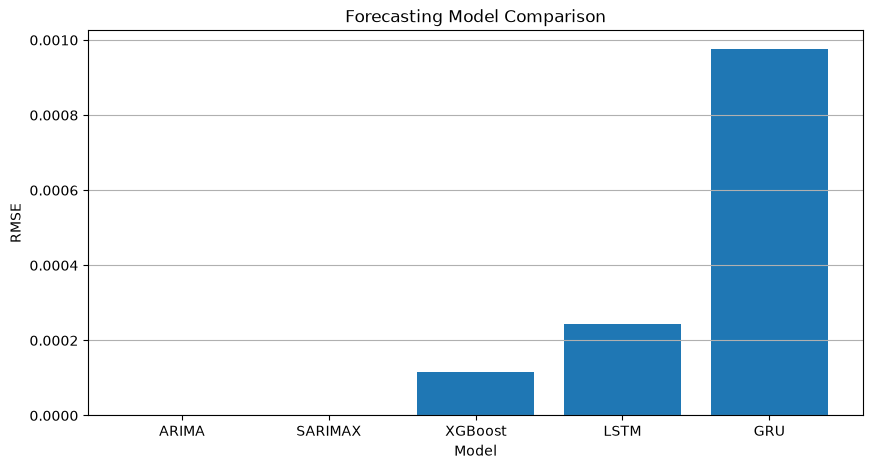

In [39]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Forecasting Model Comparison")

plt.grid(axis="y")

plt.show()

In [40]:
xgb_path = os.path.join(
    MODEL_DIR,
    "DEM_xgboost.json"
)

xgb_model.save_model(
    xgb_path
)

print(
    "XGBoost saved:",
    xgb_path
)

XGBoost saved: E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_xgboost.json


In [41]:
scaler_path = os.path.join(
    MODEL_DIR,
    "DEM_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print(
    "Scaler saved:",
    scaler_path
)

Scaler saved: E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_scaler.pkl


In [42]:
lstm_path = os.path.join(
    MODEL_DIR,
    "DEM_lstm.pt"
)

torch.save({

    "model_type": "LSTM",

    "input_size": 1,

    "hidden_size": 64,

    "num_layers": 2,

    "sequence_length": SEQUENCE_LENGTH,

    "model_state_dict":
        lstm_model.state_dict(),

    "metrics": {

        "MAE":
            float(lstm_metrics[0]),

        "RMSE":
            float(lstm_metrics[1]),

        "MAPE":
            float(lstm_metrics[2]),

        "R2":
            float(lstm_metrics[3])
    }

}, lstm_path)

print(
    "LSTM saved:",
    lstm_path
)

LSTM saved: E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_lstm.pt


In [43]:
gru_path = os.path.join(
    MODEL_DIR,
    "DEM_gru.pt"
)

torch.save({

    "model_type": "GRU",

    "input_size": 1,

    "hidden_size": 64,

    "num_layers": 2,

    "sequence_length": SEQUENCE_LENGTH,

    "model_state_dict":
        gru_model.state_dict(),

    "metrics": {

        "MAE":
            float(gru_metrics[0]),

        "RMSE":
            float(gru_metrics[1]),

        "MAPE":
            float(gru_metrics[2]),

        "R2":
            float(gru_metrics[3])
    }

}, gru_path)

print(
    "GRU saved:",
    gru_path
)

GRU saved: E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_gru.pt


In [44]:
if best_model_name == "LSTM":

    best_model_path = os.path.join(
        MODEL_DIR,
        "DEM_best_model.pt"
    )

    torch.save({

        "model_type": "LSTM",

        "input_size": 1,

        "hidden_size": 64,

        "num_layers": 2,

        "sequence_length": SEQUENCE_LENGTH,

        "model_state_dict":
            lstm_model.state_dict(),

        "metrics": {

            "MAE":
                float(lstm_metrics[0]),

            "RMSE":
                float(lstm_metrics[1]),

            "MAPE":
                float(lstm_metrics[2]),

            "R2":
                float(lstm_metrics[3])
        }

    }, best_model_path)

In [46]:
elevation_min = df["elevation_mean_m"].min()
elevation_max = df["elevation_mean_m"].max()

print("Minimum elevation:", elevation_min)
print("Maximum elevation:", elevation_max)

Minimum elevation: 2721.837517392416
Maximum elevation: 2721.837517392416


In [47]:
def elevation_risk_score(
    elevation,
    min_elevation,
    max_elevation
):

    if max_elevation == min_elevation:

        return 0.0

    score = (
        elevation - min_elevation
    ) / (
        max_elevation - min_elevation
    )

    return float(
        np.clip(score, 0, 1)
    )

In [48]:
def risk_level(score):

    if score < 0.2:
        return "LOW"

    elif score < 0.4:
        return "MODERATE"

    elif score < 0.6:
        return "HIGH"

    elif score < 0.8:
        return "VERY HIGH"

    else:
        return "EXTREME"

In [49]:
if best_model_name == "LSTM":

    final_prediction = float(
        lstm_pred[-1]
    )

elif best_model_name == "GRU":

    final_prediction = float(
        gru_pred[-1]
    )

elif best_model_name == "ARIMA":

    final_prediction = float(
        arima_pred[-1]
    )

elif best_model_name == "SARIMAX":

    final_prediction = float(
        sarimax_pred[-1]
    )

elif best_model_name == "XGBoost":

    final_prediction = float(
        xgb_pred[-1]
    )

else:

    raise ValueError(
        "Unknown model"
    )

print(
    "Final predicted elevation:",
    final_prediction
)

Final predicted elevation: 2721.837517392416


In [50]:
final_risk_score = elevation_risk_score(
    final_prediction,
    elevation_min,
    elevation_max
)

final_risk_level = risk_level(
    final_risk_score
)

print(
    "Risk score:",
    final_risk_score
)

print(
    "Risk level:",
    final_risk_level
)

Risk score: 0.0
Risk level: LOW


In [51]:
final_output = {

    "dataset": "DEM",

    "best_model":
        best_model_name,

    "predicted_elevation_m":
        round(final_prediction, 4),

    "terrain_risk_score":
        round(final_risk_score, 4),

    "terrain_risk_level":
        final_risk_level
}

print(final_output)

{'dataset': 'DEM', 'best_model': 'ARIMA', 'predicted_elevation_m': 2721.8375, 'terrain_risk_score': 0.0, 'terrain_risk_level': 'LOW'}


In [52]:
import json

metadata = {

    "dataset": "DEM",

    "best_model": best_model_name,

    "sequence_length": SEQUENCE_LENGTH,

    "input_size": 1,

    "hidden_size": 64,

    "num_layers": 2,

    "predicted_elevation_m":
        float(final_prediction),

    "terrain_risk_score":
        float(final_risk_score),

    "terrain_risk_level":
        final_risk_level,

    "metrics":
        results.to_dict(orient="records")
}

metadata_path = os.path.join(
    MODEL_DIR,
    "DEM_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print(
    "Metadata saved:",
    metadata_path
)

Metadata saved: E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_metadata.json


In [53]:
print("\nSaved model files:\n")

for file in os.listdir(MODEL_DIR):

    print(file)


Saved model files:

DEM_gru.pt
DEM_lstm.pt
DEM_metadata.json
DEM_scaler.pkl
DEM_xgboost.json


In [55]:
best_model_name = results.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: ARIMA


In [56]:
best_model_path = os.path.join(
    MODEL_DIR,
    "DEM_best_model.pt"
)

if best_model_name == "LSTM":

    torch.save({
        "model_type": "LSTM",
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 2,
        "sequence_length": SEQUENCE_LENGTH,
        "model_state_dict": lstm_model.state_dict(),
        "metrics": {
            "MAE": float(lstm_metrics[0]),
            "RMSE": float(lstm_metrics[1]),
            "MAPE": float(lstm_metrics[2]),
            "R2": float(lstm_metrics[3])
        }
    }, best_model_path)


elif best_model_name == "GRU":

    torch.save({
        "model_type": "GRU",
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 2,
        "sequence_length": SEQUENCE_LENGTH,
        "model_state_dict": gru_model.state_dict(),
        "metrics": {
            "MAE": float(gru_metrics[0]),
            "RMSE": float(gru_metrics[1]),
            "MAPE": float(gru_metrics[2]),
            "R2": float(gru_metrics[3])
        }
    }, best_model_path)


else:
    print(
        f"Best model is {best_model_name}, "
        "which is not a PyTorch model."
    )

print("Best model saved at:")
print(best_model_path)

Best model is ARIMA, which is not a PyTorch model.
Best model saved at:
E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_best_model.pt


In [57]:
print("\nSaved model files:\n")

for file in os.listdir(MODEL_DIR):
    print(file)


Saved model files:

DEM_gru.pt
DEM_lstm.pt
DEM_metadata.json
DEM_scaler.pkl
DEM_xgboost.json


In [58]:
arima_fit = arima_model.fit()

In [59]:
import os
import joblib

best_model_path = os.path.join(
    MODEL_DIR,
    "DEM_best_model.pkl"
)

joblib.dump(
    arima_fit,
    best_model_path
)

print("Best ARIMA model saved successfully!")
print(best_model_path)

Best ARIMA model saved successfully!
E:\MY projects\Flash Flood Prediction Project\models\DEM\DEM_best_model.pkl


In [60]:
print("\nSaved model files:\n")

for file in os.listdir(MODEL_DIR):
    print(file)


Saved model files:

DEM_best_model.pkl
DEM_gru.pt
DEM_lstm.pt
DEM_metadata.json
DEM_scaler.pkl
DEM_xgboost.json
